In [1]:
import torch
import torch.nn as nn
from torch import Tensor
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader,SubsetRandomSampler,ConcatDataset
import torch.nn.functional as F

from model import SeqNN

In [2]:
# Set the default tensor type to float32
torch.set_default_dtype(torch.float32)

# Check the default tensor dtype
print("Default tensor dtype:", torch.get_default_dtype())

Default tensor dtype: torch.float32


In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(device)

cuda:0


In [4]:
# Load the entire model (architecture + weights)
model = torch.load("model.pth")

/tmp/SLURM_116978/ipykernel_513043/336259025.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("model.pth")


In [5]:
model = model.to(device)

In [6]:
# Set the model to evaluation mode (important for inference)
model.eval()

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (re_lu): ReLU()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 96, kernel_size=(11,), stride=(1,), padding=(5,), bias=False)
    (batch_norm): BatchNorm1d(96, eps=0.001, momentum=0.9265, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(96, 96, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(96, eps=0.001, momentum=0.9265, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(96, 96, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(96, eps=0.001, momentum=0.9265, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size

In [7]:
from torchinfo import summary

summary(model, input_size=(2, 4, 1048576), col_names=["output_size", "num_params"])

Layer (type:depth-idx)                   Output Shape              Param #
SeqNN                                    [2, 5, 99681]             --
├─StochasticReverseComplement: 1-1       [2, 4, 1048576]           --
├─StochasticShift: 1-2                   [2, 4, 1048576]           --
├─ReLU: 1-3                              [2, 4, 1048576]           --
├─ConvBlock: 1-4                         [2, 96, 524288]           --
│    └─Conv1d: 2-1                       [2, 96, 1048576]          4,224
│    └─BatchNorm1d: 2-2                  [2, 96, 1048576]          192
│    └─MaxPool1d: 2-3                    [2, 96, 524288]           --
├─ConvTower: 1-5                         [2, 96, 512]              --
│    └─Sequential: 2-4                   [2, 96, 512]              --
│    │    └─ReLU: 3-1                    [2, 96, 524288]           --
│    │    └─Conv1d: 3-2                  [2, 96, 524288]           46,080
│    │    └─BatchNorm1d: 3-3             [2, 96, 524288]           192
│    │

In [8]:
from pyfaidx import Fasta

In [9]:
fasta_file = "/project/fudenber_735/genomes/hg38/hg38.fa"
genome = Fasta(fasta_file)

region = "chr12"
start = 115163136
end = 116211712

# region = "chr11"
# start = 75429888
# end = 76478464

# region = "chr15"
# start = 63281152
# end = 64329728

In [10]:
sequence = genome[region][start:end]

# sequence = "A" * 1048576

In [11]:
import numpy as np

In [12]:
def one_hot_encode_sequence(sequence_obj):
    # Convert pyfaidx.Sequence object to string
    sequence = str(sequence_obj).upper()

    # Define the mapping from bases to integers
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}

    # Step 1: Encode the sequence to integers
    encoded_sequence = np.array([base_to_int[base] for base in sequence])

    # Step 2: One-hot encode the sequence
    one_hot_encoded = np.zeros((4, len(encoded_sequence)), dtype=np.float32)
    one_hot_encoded[encoded_sequence, np.arange(len(encoded_sequence))] = 1

    # Step 3: Expand the dimensions to [1, 4, sequence_length]
    input_sequence = np.expand_dims(one_hot_encoded, axis=0)

    return input_sequence

In [13]:
input_sequence = one_hot_encode_sequence(sequence)

In [14]:
input_sequence.shape

(1, 4, 1048576)

In [15]:
input_sequence[:,:,0:5]

array([[[0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0.],
        [1., 1., 0., 0., 0.],
        [0., 0., 0., 1., 0.]]], dtype=float32)

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

def hook_fn(module, input, output):
    # Extract the slice for the first channel
    first_channel = output[0, 0, :, :]

    # Print min and max values of that slice
    print(f"Min value: {first_channel.min().item()}")
    print(f"Max value: {first_channel.max().item()}")
    
    # Print the shape of the output and a slice of the output for inspection
    print("Output shape:", output.shape)
    print("Output slice (output[:, 0, :, :]):\n", output[:, 0, :, :])

    # Plot the heatmap for the first channel (output[:, 0, :, :])
    plt.figure(figsize=(8, 6))
    sns.heatmap(first_channel.cpu().detach().numpy(), cmap='viridis', cbar=True, vmin=-0.5, vmax=0.7)
    plt.title(f'Heatmap of output[:, 0, :, :]')
    plt.show()

In [17]:
# after first convolution
# hook_handle = model.conv_block_1.conv.register_forward_hook(hook_fn)

# after first batch norm
# hook_handle = model.conv_block_1.batch_norm.register_forward_hook(hook_fn)

# after max pooling
# hook_handle = model.conv_block_1.pool.register_forward_hook(hook_fn)

# first conv in conv_tower
hook_handle = model.cropping_2d.register_forward_hook(hook_fn)

In [18]:
# Convert the NumPy array to a PyTorch tensor
input_sequence_tensor = torch.tensor(input_sequence)

Min value: -0.7242882251739502
Max value: 0.7419003248214722
Output shape: torch.Size([1, 48, 448, 448])
Output slice (output[:, 0, :, :]):
 tensor([[[ 0.0447,  0.0886,  0.0668,  ...,  0.0368,  0.0699, -0.0256],
         [ 0.0886,  0.2322,  0.2239,  ...,  0.0053, -0.0017, -0.1854],
         [ 0.0668,  0.2239,  0.2153,  ..., -0.0193, -0.0244, -0.0340],
         ...,
         [ 0.0368,  0.0053, -0.0193,  ...,  0.1828,  0.1888,  0.1075],
         [ 0.0699, -0.0017, -0.0244,  ...,  0.1888,  0.1965,  0.1139],
         [-0.0256, -0.1854, -0.0340,  ...,  0.1075,  0.1139,  0.0342]]])


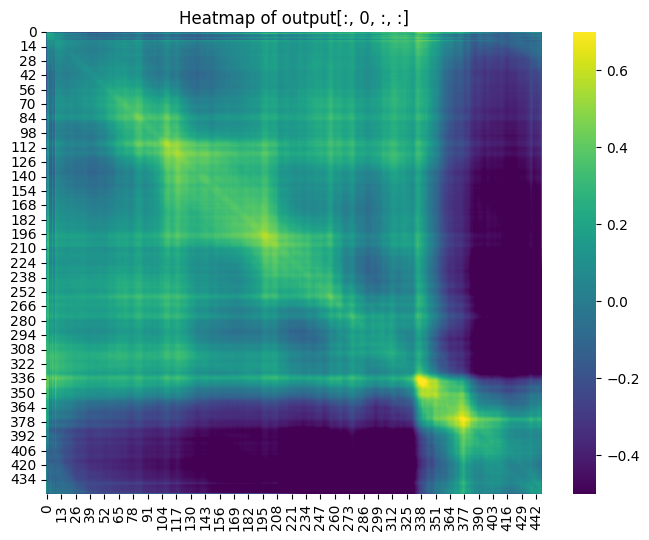

In [19]:
model.eval()
with torch.no_grad():
    model(input_sequence_tensor)

In [20]:
# Remove the hook after usage
hook_handle.remove()

In [21]:
# Convert the NumPy array to a PyTorch tensor
input_sequence_tensor = torch.tensor(input_sequence)

# Now you can move the tensor to the desired device (e.g., GPU or CPU)
x = input_sequence_tensor.to(device)

In [22]:
model.eval()
with torch.no_grad():
    example_output = model(x, training=False)

In [23]:
example_output[:,0:5,0:10]

tensor([[[-0.3407, -0.3198, -0.3388, -0.3952, -0.4215, -0.4409, -0.3293,
          -0.3252, -0.3126, -0.3115],
         [-0.2279, -0.2201, -0.2343, -0.2777, -0.2927, -0.3108, -0.2407,
          -0.2384, -0.2265, -0.2261],
         [-0.3481, -0.3372, -0.3463, -0.3828, -0.3968, -0.4070, -0.3714,
          -0.3633, -0.3576, -0.3558],
         [-0.4503, -0.4290, -0.4444, -0.4989, -0.5247, -0.5405, -0.4655,
          -0.4573, -0.4487, -0.4471],
         [-0.2814, -0.2722, -0.2784, -0.3097, -0.3205, -0.3273, -0.3042,
          -0.2949, -0.2893, -0.2860]]], device='cuda:0')

In [24]:
print(example_output.dtype)

torch.float32


In [25]:
# Helper function to set diagonal elements to a specific value
def set_diag(matrix, value, k):
    # Explicitly set the diagonal to 'value' (in this case, np.nan) for each k
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu(vector_repr, matrix_len, num_diags):
    # Ensure vector_repr is a NumPy array (if it's a PyTorch tensor, convert it)
    if isinstance(vector_repr, torch.Tensor):
        vector_repr = vector_repr.detach().flatten().cpu().numpy()  # Flatten and convert to NumPy array

    # Initialize a zero matrix of shape (matrix_len, matrix_len)
    z = np.zeros((matrix_len, matrix_len))

    # Get the indices for the upper triangular matrix
    triu_tup = np.triu_indices(matrix_len, num_diags)

    # Assign the values from the vector_repr to the upper triangular part of the matrix
    z[triu_tup] = vector_repr

    # Set the diagonals specified by num_diags to np.nan
    for i in range(-num_diags + 1, num_diags):
        set_diag(z, np.nan, i)

    # Ensure the matrix is symmetric
    return z + z.T

In [26]:
target0 = example_output[:,0,:]

In [27]:
target0.shape

torch.Size([1, 99681])

In [28]:
matrix = from_upper_triu(target0, matrix_len=448, num_diags=2)

In [29]:
np.nanmean(matrix)

np.float64(-0.5052192129092412)

<Figure size 800x800 with 0 Axes>

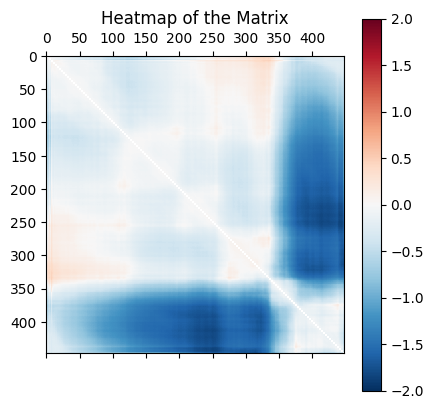

In [30]:
import matplotlib.pyplot as plt

# Plot the matrix
plt.figure(figsize=(8, 8))
plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-2, vmax=2)
plt.colorbar()
plt.title('Heatmap of the Matrix')
plt.show()